# Taxonomy LLM Merge

Pipeline pairwise-merge LLM par-dessus l'arbre HAC du notebook 4.

1. **Seed leaves**: pour chaque feuille HAC, sélectionner les 5 paraphrases les plus centrales (cosine au centroïde) et demander à Mistral un label snake_case + description.
2. **Merge loop**: itérativement, demander à Mistral de proposer des regroupements N-aires (2-5 nœuds) parmi le pool courant. On applique les merges au-dessus du seuil de confiance ; on s'arrête quand plus rien n'est défendable.
3. **Visualize + persist**: arbre Plotly + JSON sous `data/taxonomy/llm_tree/`.


## 0. Setup

In [2]:
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))

from logging_config import setup_logging

setup_logging()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import json
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv(Path().resolve().parent / ".env")
assert os.getenv("MISTRAL_API_KEY"), "MISTRAL_API_KEY missing — populate .env"

DATA_DIR = Path("../data")
HAC_DIR = DATA_DIR / "taxonomy" / "hac_clustering"  # outputs of notebook 4
OUT_DIR = DATA_DIR / "taxonomy" / "llm_tree"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PROVIDER = "mistral"
K_PARAPHRASES = 5
MAX_ITER = 10
CONF_THRESHOLD = 0.6
MIN_MEAN_CONF = 0.5
RANDOM_SEED = 42

## 1. Load clustering artefacts (from notebook 4)

Trois fichiers produits par notebook 4 dans `data/taxonomy/hac_clustering/` :
- `clustering_full.parquet` — DataFrame post-filtre avec `paraphrase_task`, `hac_cluster_id`, etc.
- `embeddings.npy` — embeddings alignés sur le DataFrame
- `taxo_tree.json` — arbre HAC produit par `cut_tree_adaptive`

In [4]:
from src.taxonomy.hac_utils import TaxoNode

DF_PATH = HAC_DIR / "clustering_task_full.parquet"
EMB_PATH = HAC_DIR / "embeddings_task_full.npy"
TREE_PATH = HAC_DIR / "taxo_tree_task.json"

for p in (DF_PATH, EMB_PATH, TREE_PATH):
    assert p.exists(), f"missing artefact: {p} — re-run notebook 4 to regenerate"

mistral_taxonomy = pd.read_parquet(DF_PATH)
embeddings_arr = np.load(EMB_PATH)
with TREE_PATH.open(encoding="utf-8") as f:
    taxo_tree = TaxoNode.from_dict(json.load(f))

assert len(embeddings_arr) == len(mistral_taxonomy), (
    f"DF/embeddings mismatch: {len(mistral_taxonomy)} vs {len(embeddings_arr)}"
)

leaf_nodes = taxo_tree._leaf_nodes()
print(f"Papers: {len(mistral_taxonomy)} | Embeddings: {embeddings_arr.shape}")
print(
    f"HAC leaves: {len(leaf_nodes)} | sizes: {sorted([len(n.leaves) for n in leaf_nodes], reverse=True)}"
)

Papers: 1595 | Embeddings: (1595, 768)
HAC leaves: 164 | sizes: [46, 44, 43, 41, 40, 39, 38, 37, 33, 30, 30, 28, 25, 23, 22, 20, 19, 19, 19, 18, 18, 18, 18, 18, 17, 17, 16, 16, 15, 15, 15, 15, 14, 14, 13, 13, 13, 12, 12, 12, 12, 11, 11, 11, 10, 10, 10, 10, 9, 9, 9, 9, 9, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1]


## 2. Seed leaves (LLM-generated label + description per HAC cluster)

In [ ]:
from src.taxonomy.llm_merge import seed_leaves_batch_submit

job_id = seed_leaves_batch_submit(
    taxo_tree,
    mistral_taxonomy,
    embeddings_arr,
    paraphrase_col="paraphrase_task",
    model="mistral-large-latest",
)
print(f"Submitted seed_leaves batch job: {job_id}")


In [ ]:
from src.taxonomy.llm_merge import seed_leaves_batch_results

# Retrieve results from the batch job
leaves = seed_leaves_batch_results(
    job_id,
    taxo_tree,
    mistral_taxonomy,
    embeddings_arr,
    paraphrase_col="paraphrase_task",
)
print(f"Retrieved {len(leaves)} leaves from batch job {job_id}")


In [ ]:
seed_labels_test = pd.DataFrame(
    [
        {
            "id": leave.id,
            "label": leave.label,
            "size": leave.size,
            "coherence": round(leave.coherence, 2),
            "description": leave.description,
            "paraphrases": "\n".join(f"• {p}" for p in leave.paraphrases),
            "papers": "\n".join(
                f"{row.bibkey} — {row.title}"
                for row in mistral_taxonomy.iloc[leave.member_indices].itertuples()
            ),
        }
        for leave in leaves
    ]
)


In [ ]:
# Save seeded leaves for step-by-step testing
seed_leaves_path = OUT_DIR / "leaves_seed.json"
with seed_leaves_path.open("w", encoding="utf-8") as f:
    json.dump([leave.model_dump() for leave in leaves], f, ensure_ascii=False, indent=2)
print(f"Saved seeded leaves to {seed_leaves_path}")

## 3. Iterative pairwise-merge loop

In [5]:
from src.taxonomy.llm_merge import LeafCluster

leaves_path = OUT_DIR / "leaves_seed.json"
with leaves_path.open(encoding="utf-8") as f:
    leaves = [LeafCluster.model_validate(d) for d in json.load(f)]
print(f"Reloaded {len(leaves)} leaves from {leaves_path}")

Reloaded 164 leaves from ..\data\taxonomy\llm_tree\leaves_seed.json


In [5]:
N_LEAVES_TEST = 40
leaves_test = sorted(leaves, key=lambda x: x.size, reverse=True)[:N_LEAVES_TEST]

In [5]:
leaves_sorted = sorted(leaves, key=lambda x: x.size, reverse=True)
leaves_test = (
    leaves_sorted[:25]  # gros
    + leaves_sorted[
        len(leaves_sorted) // 2 - 10 : len(leaves_sorted) // 2 + 10
    ]  # milieu
    + leaves_sorted[-15:]  # queue
)
seen = set()
leaves_test = [l for l in leaves_test if not (l.id in seen or seen.add(l.id))]

In [11]:
# Save seeded leaves for step-by-step testing
seed_leaves_path = OUT_DIR / "leaves_seed_test_stratif.json"
with seed_leaves_path.open("w", encoding="utf-8") as f:
    json.dump(
        [leave.model_dump() for leave in leaves_test], f, ensure_ascii=False, indent=2
    )
print(f"Saved seeded leaves to {seed_leaves_path}")

Saved seeded leaves to ..\data\taxonomy\llm_tree\leaves_seed_test_stratif.json


In [12]:
from src.taxonomy.llm_merge import (
    pairwise_merge_loop,
    assert_tree_invariants,
    save_llm_tree,
)

WINDOW_SIZE = 10

nodes_by_id, roots, iteration_log = await pairwise_merge_loop(
    leaves,
    embeddings=embeddings_arr,
    provider=PROVIDER,
    max_iterations=MAX_ITER,
    confidence_threshold=CONF_THRESHOLD,
    paraphrases_per_node=K_PARAPHRASES,
    window_size=WINDOW_SIZE,
    seed=RANDOM_SEED,
    max_concurrent_windows=3,
)

n_internals = sum(1 for n in nodes_by_id.values() if n.children)
print(f"Final pool (forest roots): {len(roots)}")
print(
    f"Total nodes: {len(nodes_by_id)} ({len(leaves)} leaves + {n_internals} internals)"
)

save_llm_tree(leaves, nodes_by_id, roots, iteration_log, OUT_DIR)
print(f"Saved pairwise merge artefacts to {OUT_DIR}")

pd.DataFrame(iteration_log)

2026-05-01 18:09:54  INFO      Iter 1: 78 proposed, 19 accepted (mean conf 0.85), support mean/min/max 1.68/1/4, consensus=8 unique=11, pool now 137
2026-05-01 18:21:41  INFO      Iter 2: 55 proposed, 20 accepted (mean conf 0.83), support mean/min/max 1.60/1/5, consensus=8 unique=12, pool now 117
2026-05-01 18:29:48  INFO      Iter 3: 25 proposed, 10 accepted (mean conf 0.83), support mean/min/max 1.10/1/2, consensus=1 unique=9, pool now 104
2026-05-01 18:36:36  INFO      Iter 4: 16 proposed, 9 accepted (mean conf 0.82), support mean/min/max 1.22/1/2, consensus=2 unique=7, pool now 95
2026-05-01 18:42:56  INFO      Iter 5: 10 proposed, 10 accepted (mean conf 0.83), support mean/min/max 1.00/1/1, consensus=0 unique=10, pool now 85
2026-05-01 18:47:58  INFO      Iter 6: 4 proposed, 3 accepted (mean conf 0.85), support mean/min/max 1.33/1/2, consensus=1 unique=2, pool now 82
2026-05-01 18:53:17  INFO      Iter 7: 6 proposed, 4 accepted (mean conf 0.80), support mean/min/max 1.25/1/2, cons

,iteration,pool_size_before,pool_size,n_proposed,n_accepted,mean_confidence,n_windows,n_invalid,n_overlap_rejected,accepted_support_counts,accepted_support_mean,accepted_support_min,accepted_support_max,n_consensus_merges,n_unique_merges,llm_reasoning_by_window,kept_merge_justifications,stop_reason
0,1,164.0,137,78.0,19.0,0.850000,79.0,1.0,58.0,"[3, 3, 3, 2, 2, 4, 1, 2, 1, 1, 1, 1, 1, 1, 1, ...",1.684211,1.0,4.0,8.0,11.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['leaf_53', 'leaf_55', 'leaf...",NaN
1,2,137.0,117,55.0,20.0,0.830000,72.0,0.0,35.0,"[5, 2, 2, 3, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...",1.600000,1.0,5.0,8.0,12.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['merge_01_00', 'merge_01_17...",NaN
2,3,117.0,104,25.0,10.0,0.830000,58.0,0.0,15.0,"[2, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.100000,1.0,2.0,1.0,9.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['merge_02_00', 'leaf_34', '...",NaN
3,4,104.0,95,16.0,9.0,0.816667,52.0,0.0,7.0,"[1, 1, 2, 2, 1, 1, 1, 1, 1]",1.222222,1.0,2.0,2.0,7.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['leaf_51', 'merge_03_00'], ...",NaN
4,5,95.0,85,10.0,10.0,0.835000,50.0,0.0,0.0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",1.000000,1.0,1.0,0.0,10.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['merge_02_11', 'leaf_89'], ...",NaN
5,6,85.0,82,4.0,3.0,0.850000,44.0,0.0,1.0,"[1, 2, 1]",1.333333,1.0,2.0,1.0,2.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['merge_05_02', 'merge_05_08...",NaN
6,7,82.0,78,6.0,4.0,0.800000,44.0,0.0,2.0,"[1, 1, 2, 1]",1.250000,1.0,2.0,1.0,3.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['merge_04_04', 'merge_06_00...",NaN
7,8,78.0,75,4.0,3.0,0.833333,42.0,0.0,1.0,"[1, 2, 1]",1.333333,1.0,2.0,1.0,2.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['merge_03_06', 'merge_07_03...",NaN
8,9,75.0,71,5.0,4.0,0.800000,41.0,0.0,1.0,"[1, 1, 1, 1]",1.000000,1.0,1.0,0.0,4.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['merge_06_02', 'leaf_163'],...",NaN
9,10,71.0,69,2.0,2.0,0.800000,36.0,0.0,0.0,"[1, 1]",1.000000,1.0,1.0,0.0,2.0,"[{'window_index': 0, 'window_size': 10, 'reaso...","[{'children_ids': ['leaf_157', 'merge_09_01'],...",NaN


In [ ]:
# Sanity invariants
assert_tree_invariants(leaves, nodes_by_id, roots, n_papers=len(mistral_taxonomy))
print("Tree invariants OK")

In [ ]:
# Inspect roots
pd.DataFrame(
    [
        {
            "id": r,
            "label": nodes_by_id[r].label,
            "size": nodes_by_id[r].size,
            "depth": nodes_by_id[r].iteration_created,
            "n_children": len(nodes_by_id[r].children),
            "description": nodes_by_id[r].description[:120],
        }
        for r in roots
    ]
)

## 4. Visualisation

### Lecture rapide des objets

- `taxo_tree` est l'arbre source HAC: il contient tous les papiers et sert de point de départ.
- `leaves`, `roots` et `nodes_by_id` décrivent l'état courant de la forêt pairwise produite par la boucle LLM.
- `virtual_root` est une racine artificielle ajoutée seulement pour afficher cette forêt comme un arbre unique.
- `df_for_plot` est un dataframe de viz: il sert juste à enrichir l'affichage avec les labels LLM.

In [7]:
import json
from src.taxonomy.schemas import LeafCluster, MergeNode
from src.taxonomy.llm_merge import merge_tree_to_taxonode

# Fast-path for visualization: load canonical artefacts from data/taxonomy/llm_tree/
USE_SAVED_ARTEFACTS_FOR_VIZ = True
VIZ_LEAVES_PATH = OUT_DIR / "leaves.json"
VIZ_TREE_PATH = OUT_DIR / "tree.json"

if USE_SAVED_ARTEFACTS_FOR_VIZ and VIZ_TREE_PATH.exists() and VIZ_LEAVES_PATH.exists():
    with VIZ_LEAVES_PATH.open(encoding="utf-8") as f:
        leaves_viz = [LeafCluster.model_validate(d) for d in json.load(f)]
    with VIZ_TREE_PATH.open(encoding="utf-8") as f:
        tree_viz = json.load(f)
    nodes_by_id = {
        nid: MergeNode.model_validate(payload)
        for nid, payload in tree_viz["nodes"].items()
    }
    roots = list(tree_viz["roots"])
    leaves_for_viz = leaves_viz
    print(f"Loaded visualization artefacts from {OUT_DIR}")
else:
    leaves_for_viz = leaves
    print("Using in-memory merge results for visualization")

Loaded visualization artefacts from ..\data\taxonomy\llm_tree


In [9]:
from src.taxonomy.hac_utils import plot_taxo_tree
from src.taxonomy.llm_merge import merge_tree_to_taxonode

virtual_root = merge_tree_to_taxonode(nodes_by_id, roots, leaves_for_viz)

# Inject a label_col so plot_taxo_tree's _top_label can render the LLM label.
# We map each paper index → the label of its containing leaf.
leaf_label_per_paper = {}
for leaf in leaves_for_viz:
    for idx in leaf.member_indices:
        leaf_label_per_paper[idx] = leaf.label

df_for_plot = mistral_taxonomy.reset_index(drop=True).copy()
df_for_plot["llm_leaf_label"] = df_for_plot.index.map(leaf_label_per_paper)

fig = plot_taxo_tree(
    virtual_root,
    df_for_plot,
    label_col="llm_leaf_label",
    title=f"LLM Pairwise-Merge Taxonomy ({PROVIDER})",
)
# fig.write_html("llm_merge_tree.html")
fig.show(renderer="browser")

## 5. Persistence

In [ ]:
from src.taxonomy.llm_merge import save_llm_tree, load_llm_tree

save_llm_tree(leaves, nodes_by_id, roots, iteration_log, OUT_DIR)

# Round-trip check
leaves2, nodes2, roots2, log2 = load_llm_tree(OUT_DIR)
assert len(leaves2) == len(leaves)
assert set(nodes2) == set(nodes_by_id)
assert roots2 == roots
print(f"Saved + reloaded {len(nodes_by_id)} nodes from {OUT_DIR}")

In [6]:
from src.taxonomy.llm_merge import collapse_label_duplicates

# Post-process: collapse parent->child duplicate labels in saved tree.json

tree_path = OUT_DIR / "tree.json"
collapsed_tree_path = OUT_DIR / "tree_collapsed.json"
collapse_ops_path = OUT_DIR / "collapse_ops.jsonl"

with tree_path.open(encoding="utf-8") as f:
    tree_payload = json.load(f)

ops = collapse_label_duplicates(tree_payload)

with collapsed_tree_path.open("w", encoding="utf-8") as f:
    json.dump(tree_payload, f, ensure_ascii=False, indent=2)

with collapse_ops_path.open("w", encoding="utf-8") as f:
    for row in ops:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(
    f"Collapsed tree saved to {collapsed_tree_path} | "
    f"operations={len(ops)} (log: {collapse_ops_path})"
)

pd.DataFrame(ops).head(20)

Collapsed tree saved to ..\data\taxonomy\llm_tree\tree_collapsed.json | operations=35 (log: ..\data\taxonomy\llm_tree\collapse_ops.jsonl)


,removed_parent,dominant_child,absorbed,parent_label,parent_confidence
0,merge_01_04,leaf_83,[leaf_82],utterance_pragmatic_role_identification,0.90
1,leaf_83,leaf_82,[],utterance_pragmatic_role_identification,NaN
2,merge_01_08,leaf_85,[leaf_86],communicative_intent_identification,0.85
3,merge_01_10,leaf_71,[leaf_73],social_norm_adherence_judgment,0.85
4,merge_01_12,leaf_42,"[leaf_38, leaf_33]",target_dependent_sentiment_polarity,0.85
5,merge_02_00,merge_01_00,[merge_01_17],stance_detection,0.95
6,merge_01_00,merge_01_17,"[leaf_53, leaf_55, leaf_54, leaf_37, leaf_56]",stance_detection,0.95
7,merge_02_01,leaf_136,[leaf_135],claim_factual_consistency_verification,0.90
8,merge_02_02,merge_01_01,[leaf_118],natural_language_inference,0.90
9,merge_02_03,merge_01_14,[leaf_03],social_bias_identification,0.90


In [11]:
from src.taxonomy.schemas import MergeNode
from src.taxonomy.llm_merge import merge_tree_to_taxonode
from src.taxonomy.hac_utils import plot_taxo_tree


# Visualize collapsed tree
# with (OUT_DIR / "tree_collapsed.json").open(encoding="utf-8") as f:
#     collapsed_tree = json.load(f)


with (DATA_DIR / "taxonomy" / "llm_tree_postprocessed" / "tree_final.json").open(
    encoding="utf-8"
) as f:
    collapsed_tree = json.load(f)


nodes_collapsed = {
    nid: MergeNode.model_validate(payload)
    for nid, payload in collapsed_tree["nodes"].items()
}
roots_collapsed = list(collapsed_tree["roots"])
virtual_root_collapsed = merge_tree_to_taxonode(
    nodes_collapsed, roots_collapsed, leaves
)

fig_collapsed = plot_taxo_tree(
    virtual_root_collapsed,
    df_for_plot,
    label_col="llm_leaf_label",
    title=f"LLM Pairwise-Merge Taxonomy Collapsed ({PROVIDER})",
)
fig_collapsed.show(renderer="browser")
out_html = DATA_DIR / "taxonomy" / "llm_tree_postprocessed" / "tree_final_plot.html"
fig_collapsed.write_html(out_html, include_plotlyjs=True, full_html=True)

## 6. (Optional) inspect a branch in detail

In [ ]:
def print_subtree(node_id: str, depth: int = 0) -> None:
    n = nodes_by_id[node_id]
    indent = "  " * depth
    conf = f" conf={n.confidence:.2f}" if n.confidence is not None else ""
    print(
        f"{indent}- [{n.id}] {n.label} (size={n.size}, iter={n.iteration_created}){conf}"
    )
    for c in n.children:
        print_subtree(c, depth + 1)


for r in roots:
    print_subtree(r)
    print()

## 7. Distribution des tailles de racines (long-tail / Pareto)

Figure-clé pour la RQ2 : visualise la concentration de l'effort de la communauté sur quelques tâches dominantes versus la longue traîne des niches sous-représentées. Les 69 racines de l'arbre LLM (post-collapse) sont triées par taille décroissante ; la courbe cumulative met en évidence les seuils 50 / 80 / 90 %.

Saved figures\root_size_pareto.png  |  73 roots, 1505 papers, top-26 cover 80%


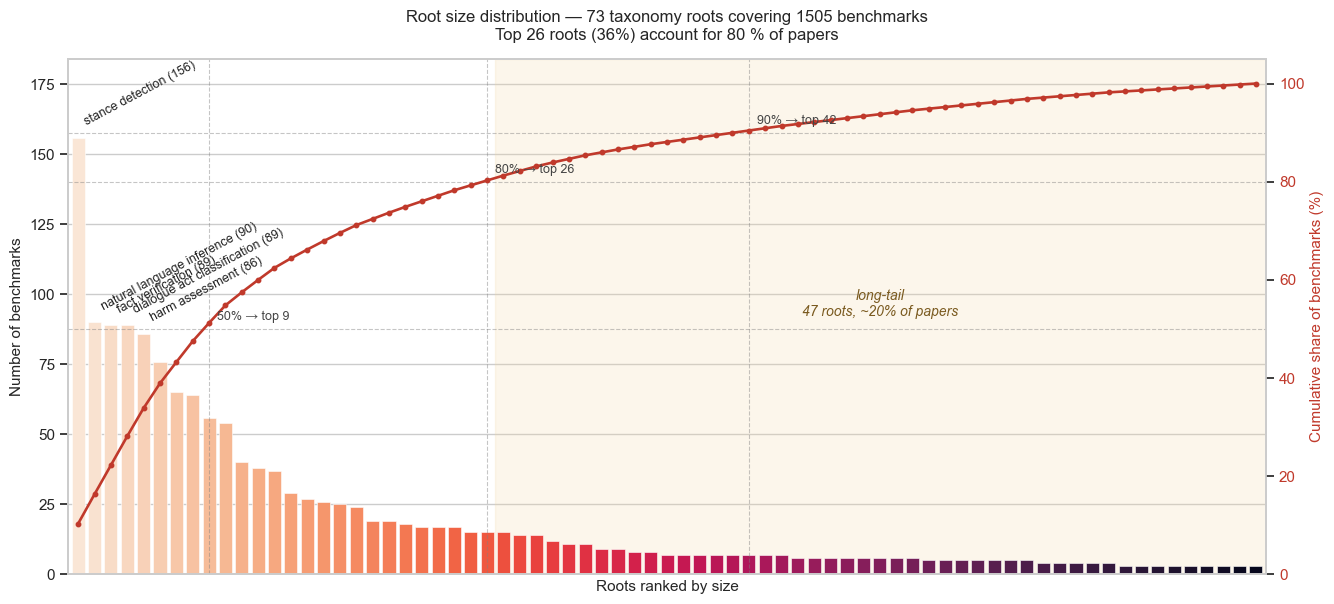

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

PARETO_TREE_PATH = DATA_DIR / "taxonomy" / "llm_tree_postprocessed" / "tree_final.json"
with PARETO_TREE_PATH.open(encoding="utf-8") as f:
    pareto_payload = json.load(f)

pareto_nodes = {
    nid: MergeNode.model_validate(p) for nid, p in pareto_payload["nodes"].items()
}
pareto_roots = list(pareto_payload["roots"])

root_data = sorted(
    [(pareto_nodes[r].label, pareto_nodes[r].size) for r in pareto_roots],
    key=lambda x: x[1],
    reverse=True,
)
labels, sizes = zip(*root_data)
sizes = np.array(sizes)
n_roots = len(sizes)
total = int(sizes.sum())
cumsum_pct = np.cumsum(sizes) / total * 100

rank_50 = int(np.searchsorted(cumsum_pct, 50) + 1)
rank_80 = int(np.searchsorted(cumsum_pct, 80) + 1)
rank_90 = int(np.searchsorted(cumsum_pct, 90) + 1)

fig, ax1 = plt.subplots(figsize=(13.5, 6.2))

bar_colors = sns.color_palette("rocket_r", n_colors=n_roots)
ax1.bar(
    range(n_roots),
    sizes,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.4,
    zorder=2,
)
ax1.set_xlabel("Roots ranked by size", fontsize=11)
ax1.set_ylabel("Number of benchmarks", fontsize=11)
ax1.set_xticks([])
ax1.set_xlim(-0.6, n_roots - 0.4)
ax1.set_ylim(0, sizes.max() * 1.18)

# Long-tail emphasis: shaded band starting where cumulative passes 80%
ax1.axvspan(rank_80 - 0.5, n_roots - 0.4, color="#f3d9a4", alpha=0.22, zorder=1)
ax1.text(
    (rank_80 + n_roots) / 2 - 0.5,
    sizes.max() * 0.62,
    f"long-tail\n{n_roots - rank_80} roots, ~20% of papers",
    ha="center",
    va="center",
    fontsize=10,
    color="#7a5a1f",
    style="italic",
)

# Annotate top-5 root labels
TOP_N = 5
for i in range(TOP_N):
    pretty = labels[i].replace("_", " ")
    ax1.annotate(
        f"{pretty} ({sizes[i]})",
        xy=(i, sizes[i]),
        xytext=(3, 7),
        textcoords="offset points",
        ha="left",
        va="bottom",
        rotation=28,
        fontsize=9,
        color="#222",
    )

# Cumulative curve on twin axis
ax2 = ax1.twinx()
ax2.plot(
    range(n_roots),
    cumsum_pct,
    color="#c0392b",
    marker="o",
    markersize=3.2,
    linewidth=1.9,
    zorder=3,
)
ax2.set_ylabel("Cumulative share of benchmarks (%)", fontsize=11, color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")
ax2.set_ylim(0, 105)
ax2.grid(False)

# Horizontal + vertical reference lines for 50 / 80 / 90 %
for thresh, rank in [(50, rank_50), (80, rank_80), (90, rank_90)]:
    ax2.axhline(thresh, ls="--", color="grey", alpha=0.45, lw=0.8)
    ax2.axvline(rank - 1, ls="--", color="grey", alpha=0.45, lw=0.8)
    ax2.annotate(
        f"{thresh}% → top {rank}",
        xy=(rank - 1, thresh),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
        color="#444",
        ha="left",
        va="bottom",
    )

ax1.set_title(
    f"Root size distribution — {n_roots} taxonomy roots covering {total} benchmarks\n"
    f"Top {rank_80} roots ({rank_80 / n_roots:.0%}) account for 80 % of papers",
    fontsize=12,
    pad=14,
)

fig.tight_layout()

FIG_PATH = Path("figures") / "root_size_pareto.png"
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_PATH, dpi=160, bbox_inches="tight")
print(f"Saved {FIG_PATH}  |  {n_roots} roots, {total} papers, top-{rank_80} cover 80%")
plt.show()